<a href="https://colab.research.google.com/github/fernandolievano/aprendizaje-automatico-1/blob/main/AA1_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico 1: Comparación de métodos de escalamiento en Scikit-learn

- Asignatura: Aprendizaje Automático 1
- Carrera: Inteligencia Artificial y Ciencia de Datos

### Librerías y Recursos

In [ ]:
import matplotlib as mpl
import numpy as np
from matplotlib import cm
from matplotlib import pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import (
    MaxAbsScaler,
    MinMaxScaler,
    Normalizer,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
    minmax_scale
)

### Setup inicial

En esta celda de código se ejecutan tres tareas para preparar los datos


1. Cargamos el dataset 'California Housing' usando la función `fetch_california_housing()` y asignamos las features en `X_full`, la variable objetivo en `y_full` y los nombres de las features en `feature_names`

2. Definimos un diccionario llamado `feature_mapping` para proporcionar etiquetas más descriptivas para algunas features del conjunto de datos.

3. Seleccionamos un subconjunto de features (`MedInc` y `AveOccup`) para trabajar con él más adelante. Encontramos sus índices en la lista original `feature_names` y luego creamos una nueva matriz `X` que contiene solo los datos para estas features seleccionadas.



In [ ]:
dataset = fetch_california_housing()
X_full, y_full = dataset.data, dataset.target
feature_names = dataset.feature_names

feature_mapping = {
    "MedInc": "Median income in block",
    "HouseAge": "Median house age in block",
    "AveRooms": "Average number of rooms",
    "AveBedrms": "Average number of bedrooms",
    "Population": "Block population",
    "AveOccup": "Average house occupancy",
    "Latitude": "House block latitude",
    "Longitude": "House block longitude",
}

features = ["MedInc", "AveOccup"]
features_idx = [feature_names.index(feature) for feature in features]
X = X_full[:, features_idx]

print(f'ids: {features_idx}')

ids: [0, 5]


### Definición de escaladores

Se define una lista llamada `distributions` que contiene diferentes veriones de los datos `X` después de aplicar varios métodos de escalado y transformación de scikit-learn.

Los métodos de escalado y transformación utilizados son:

- Unscaled Data (datos originales sin modificación)
- Standard Scaler
- Min Max Scaler
- Max Abs Scaler
- Robust Scaler
- Power Transformer (Yeo-Johnson y Box-Cox)
- Quantile Transformer (uniform y gaussian pdf)
- Normalizer

In [ ]:
distributions = [
    ("Unscaled data", X),
    ("Data after standard scaling", StandardScaler().fit_transform(X)),
    ("Data after min-max scaling", MinMaxScaler().fit_transform(X)),
    ("Data after max-abs scaling", MaxAbsScaler().fit_transform(X)),
    (
        "Data after robust scaling",
        RobustScaler(quantile_range=(25, 75)).fit_transform(X),
    ),
    (
        "Data after power transformation (Yeo-Johnson)",
        PowerTransformer(method="yeo-johnson").fit_transform(X),
    ),
    (
        "Data after pwer transformation (Box-Cox)",
        PowerTransformer(method="box-cox").fit_transform(X),
    ),
    (
        "Data after quantile transformation (uniform pdf)",
        QuantileTransformer(
            output_distribution="uniform", random_state=42
        ).fit_transform(X),
    ),
    (
        "Data after quantile transformation (gaussian pdf)",
        QuantileTransformer(
            output_distribution="normal", random_state=42
        ).fit_transform(X),
    ),
    ("Data after sample-wise L2 normalizing", Normalizer().fit_transform(X)),
]

### Normalización del target y selección de colormap

Específicamente se prepara el color bar asignando a `y` la variable objetivo escalada en un rango entre 0 y 1. Luego asignamos a `cmap` el colormap que vamos a utilizar para los gráficos `'plasma_r'` y usamos como fallback `cm.hot_r`.

In [ ]:
y = minmax_scale(y_full)

cmap = getattr(cm, "plasma_r", cm.hot_r)

### Funciones auxiliares para graficar

In [ ]:
def create_axes(title, figsize=(16, 6)):
    # se inicializa la figura principal del gráfico y se le asigna un título global
    fig = plt.figure(figsize=figsize)
    fig.suptitle(title)

    # se establecen las coordenadas y dimensiones para el primer conjunto de subplots
    left, width = 0.1, 0.22
    bottom, height = 0.1, 0.7

    # se calculan las posiciones para los histogramas marginales asociados al primer scatter plot
    bottom_h = height + 0.15
    left_h = left + width + 0.02

    # definimos los rectángulos de posición para el scatter plot principal y sus histogramas marginales
    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom_h, width, 0.1]
    rect_histy = [left_h, bottom, 0.05, height]

    # se crean los ejes para el scatter plot y los histogramas marginales de la vista principal
    ax_scatter = plt.axes(rect_scatter)
    ax_histx = plt.axes(rect_histx)
    ax_histy = plt.axes(rect_histy)

    # ajustamos las coordenadas para el segundo conjunto de subplots
    left = width + left + 0.2
    left_h = left + width + 0.02

    # se definen los rectángulos de posición para el scatter plot con zoom y sus histogramas marginales
    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom_h, width, 0.1]
    rect_histy = [left_h, bottom, 0.05, height]

    # se crean los ejes para el scatter plot con zoom y sus histogramas marginales
    ax_scatter_zoom = plt.axes(rect_scatter)

    ax_histx_zoom = plt.axes(rect_histx)
    ax_histy_zoom = plt.axes(rect_histy)

    # se ajustan las coordenadas para la barra de color que complementa los gráficos
    left, width = width + left + 0.13, 0.01

    # se define el rectángulo de posición y se crea el eje para la barra de colo
    rect_colorbar = [left, bottom, width, height]
    ax_colorbar = plt.axes(rect_colorbar)

    # devuelve una tupla que contiene los ejes para la vista principal, la vista con zoom y la barra de color
    return (
        (ax_scatter, ax_histy, ax_histx),
        (ax_scatter_zoom, ax_histy_zoom, ax_histx_zoom),
        ax_colorbar,
    )


In [ ]:
def plot_distribution(axes, X, y, hist_nbins=50, title="", x0_label="", x1_label=""):
    # se desempaquetan los ejes: ax (scatter), hist_X1 (histograma X1), hist_X0 (histograma X0)
    ax, hist_X1, hist_X0 = axes

    # seteamos tiulo y labels del gráfico
    ax.set_title(title)
    ax.set_xlabel(x0_label)
    ax.set_ylabel(x1_label)

    # se generan colores para cada punto del scatter plot usando 'y' y 'cmap'
    # y luego se dibuja el scatter plot con X[:, 0] y X[:, 1] como coordenadas
    colors = cmap(y)
    ax.scatter(X[:, 0], X[:, 1], alpha=0.5, marker="o", s=5, lw=0, c=colors)

    # se ocultan las líneas superior y derecha del recuadro
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    # se asegura que las marcas del eje X y Y se muestren en la parte inferior e izquierda
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()
    # se mueven las líneas izquierda e inferior 10 puntos hacia afuera
    ax.spines["left"].set_position(("outward", 10))
    ax.spines["bottom"].set_position(("outward", 10))

    # se establecen los límites del eje Y del histograma hist_X1
    # y luego se dibuja el histograma horizontal para X[:, 1]
    hist_X1.set_ylim(ax.get_ylim())
    hist_X1.hist(
        X[:, 1], bins=hist_nbins, orientation="horizontal", color="grey", ec="grey"
    )
    # ocultamos los ejes del histograma hist_X1
    hist_X1.axis("off")

    # se establecen los límites del eje X del histograma hist_X0 y
    # se dibuja el histograma vertical para X[:, 0]
    hist_X0.set_xlim(ax.get_xlim())
    hist_X0.hist(
        X[:, 0], bins=hist_nbins, orientation="vertical", color="grey", ec="grey"
    )
    # ocultamos los ejes del histograma hist_X0.
    hist_X0.axis("off")

### Función para crear gráfico

La función `make_plot()` se encarga de generar un gráfico completo, obteniendo datos de la lista `distributions` según el index `item_idx` y crea los ejes necesarios llamando a la función `create_axes()` para luego graficar los datos completos llamando a la función `plot_distribution()`


In [ ]:
def make_plot(item_idx):
    title, X = distributions[item_idx]
    ax_zoom_out, ax_zoom_in, ax_colorbar = create_axes(title)
    axarr = (ax_zoom_out, ax_zoom_in)
    plot_distribution(
        axarr[0],
        X,
        y,
        hist_nbins=200,
        x0_label=feature_mapping[features[0]],
        x1_label=feature_mapping[features[1]],
        title="Full data",
    )

    # zoom-in
    zoom_in_percentile_range = (0, 99)
    cutoffs_X0 = np.percentile(X[:, 0], zoom_in_percentile_range)
    cutoffs_X1 = np.percentile(X[:, 1], zoom_in_percentile_range)

    non_outliers_mask = np.all(X > [cutoffs_X0[0], cutoffs_X1[0]], axis=1) & np.all(
        X < [cutoffs_X0[1], cutoffs_X1[1]], axis=1
    )
    plot_distribution(
        axarr[1],
        X[non_outliers_mask],
        y[non_outliers_mask],
        hist_nbins=50,
        x0_label=feature_mapping[features[0]],
        x1_label=feature_mapping[features[1]],
        title="Zoom-in",
    )

    norm = mpl.colors.Normalize(y_full.min(), y_full.max())
    mpl.colorbar.ColorbarBase(
        ax_colorbar,
        cmap=cmap,
        norm=norm,
        orientation="vertical",
        label="Color mapping for values of y",
    )

### Datos Originales

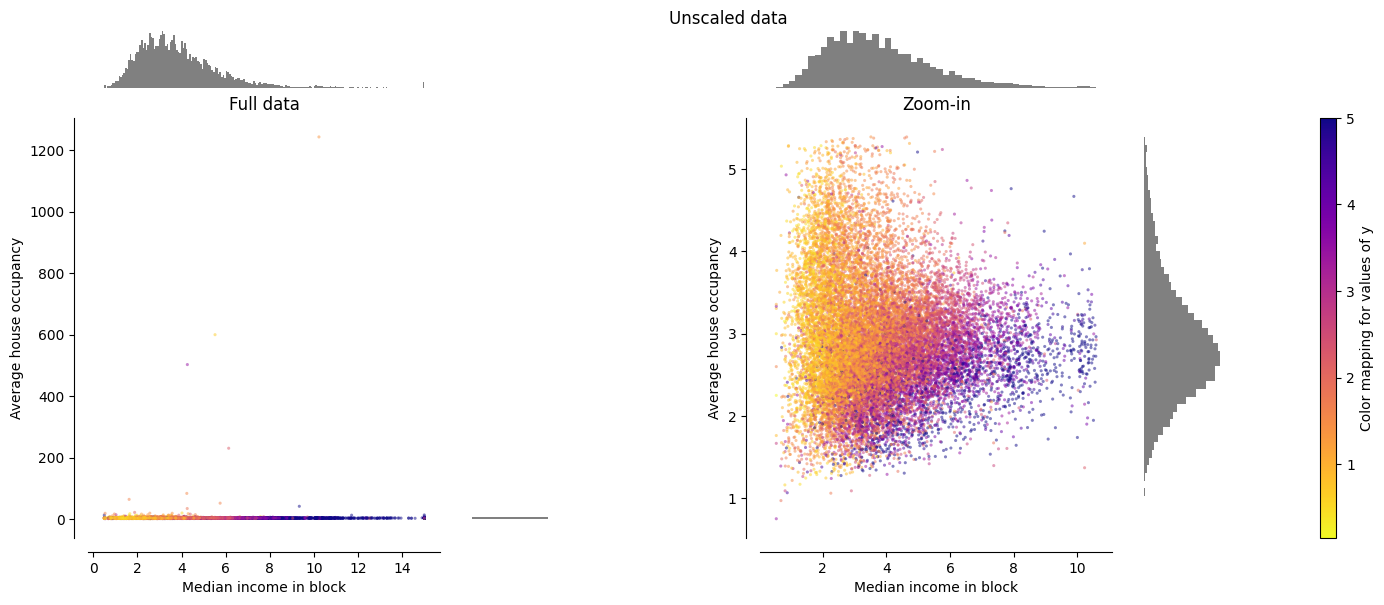

In [ ]:
make_plot(0)

### StandardScaler

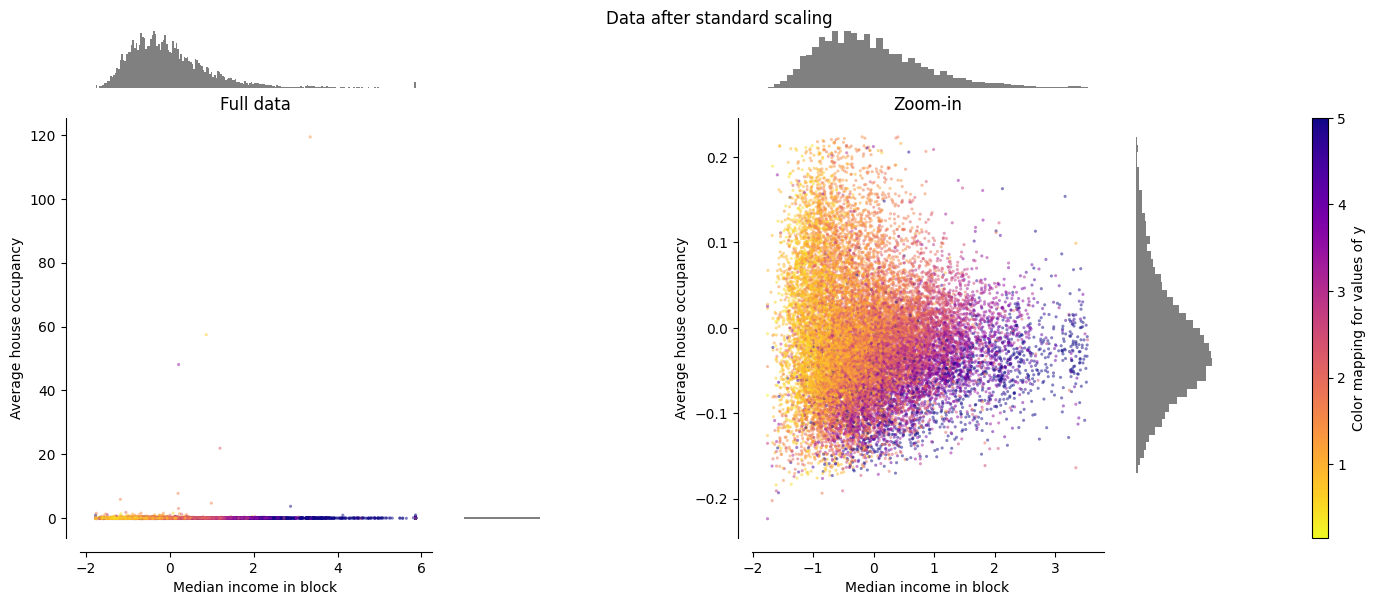

In [ ]:
make_plot(1)

### MinMaxScaler

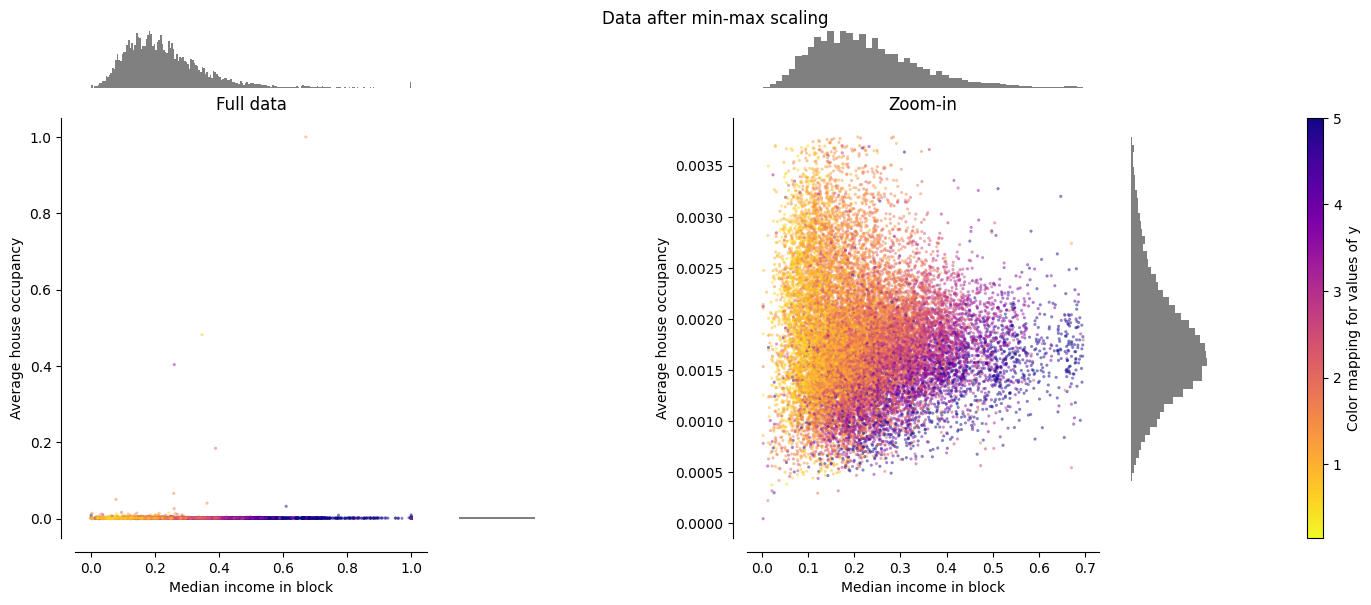

In [ ]:
make_plot(2)

### MaxAbsScaler

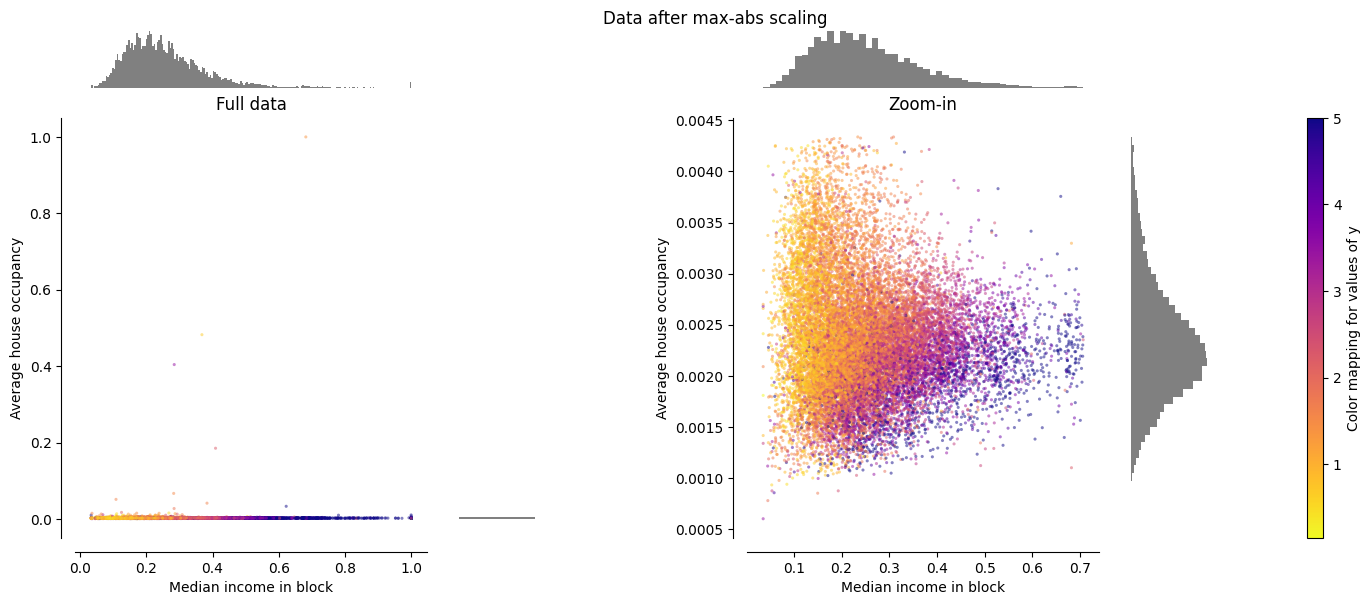

In [ ]:
make_plot(3)

### RobustScaler

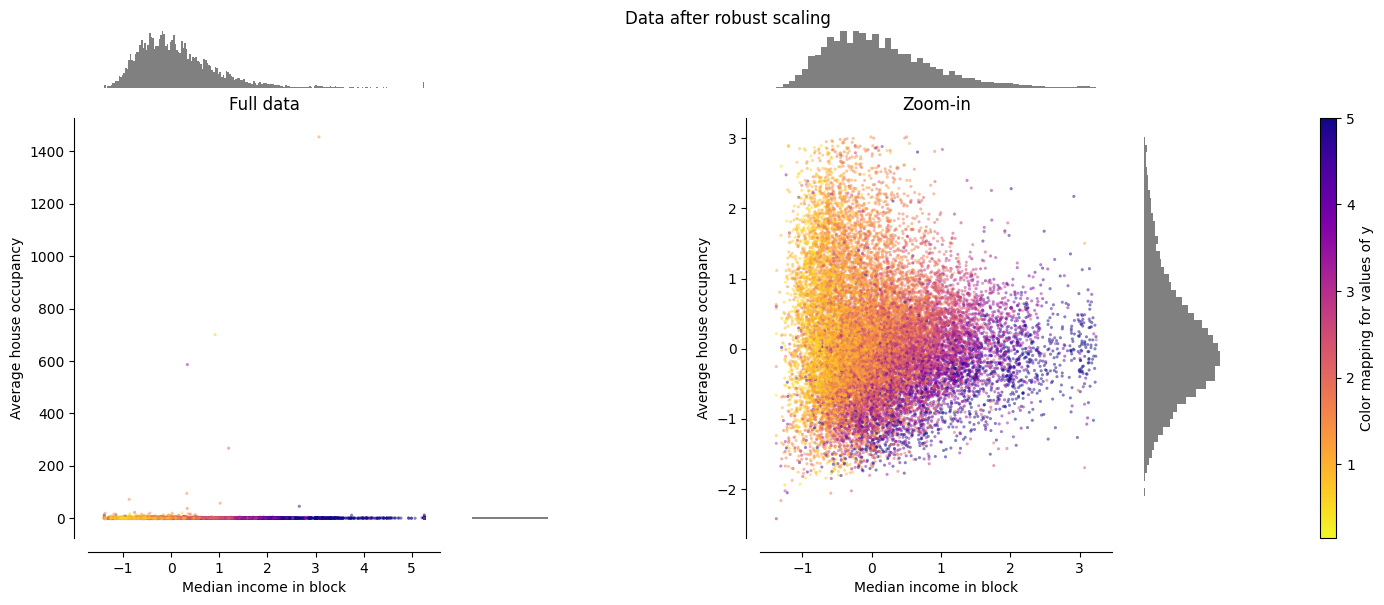

In [ ]:
make_plot(4)

### PowerTransformer

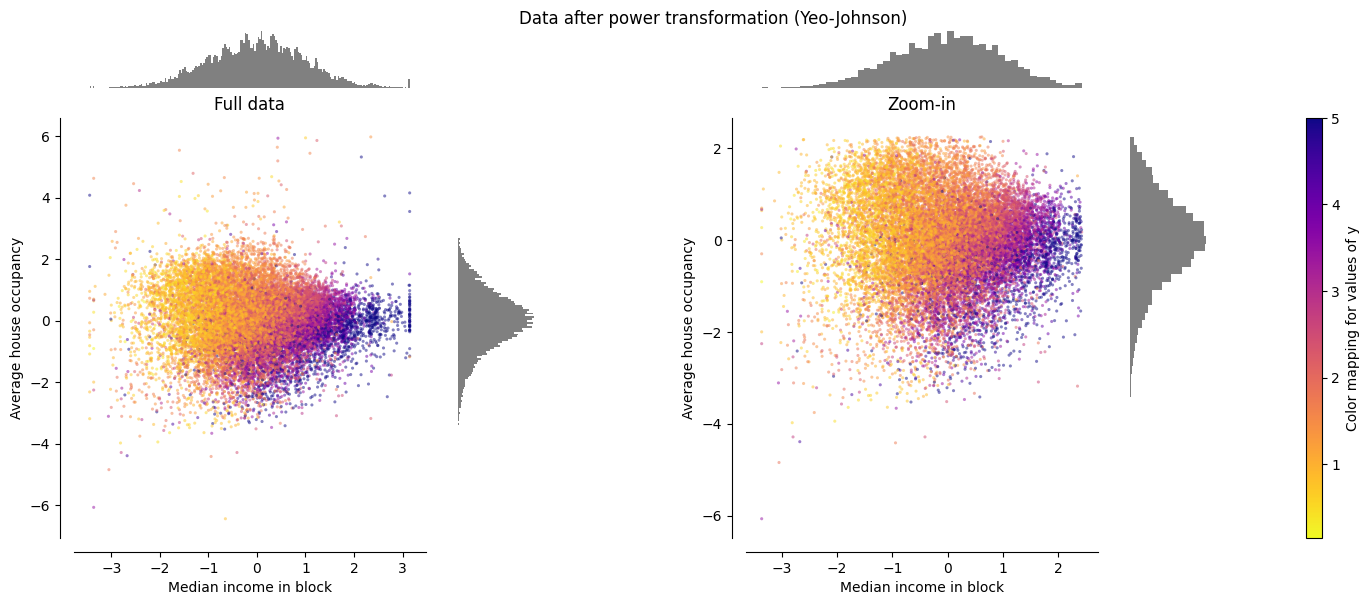

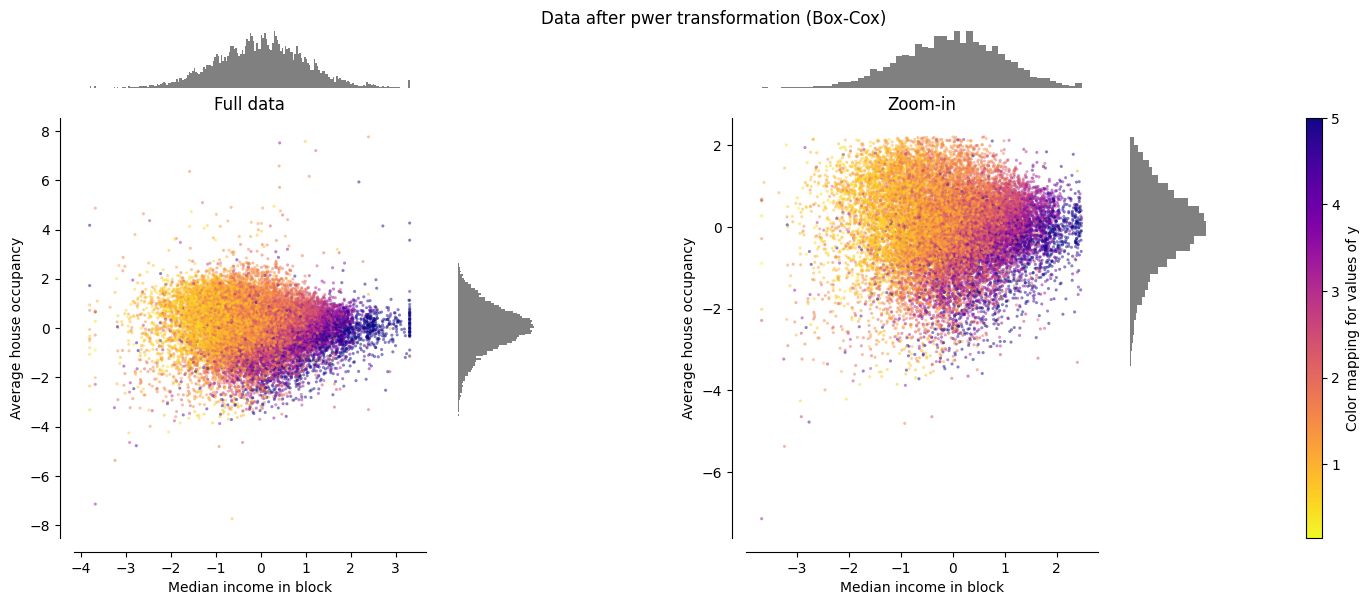

In [ ]:
make_plot(5)
make_plot(6)

### QuantileTransformer (uniform output)

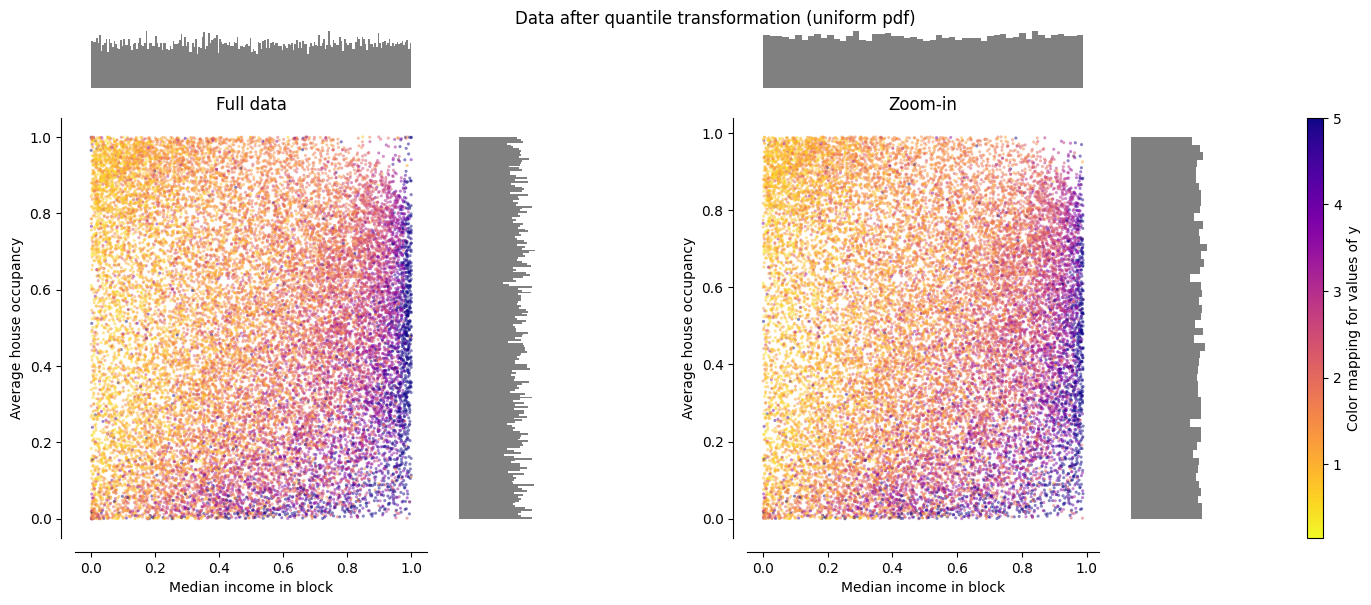

In [ ]:
make_plot(7)

### QuantileTransformer (gaussian output)

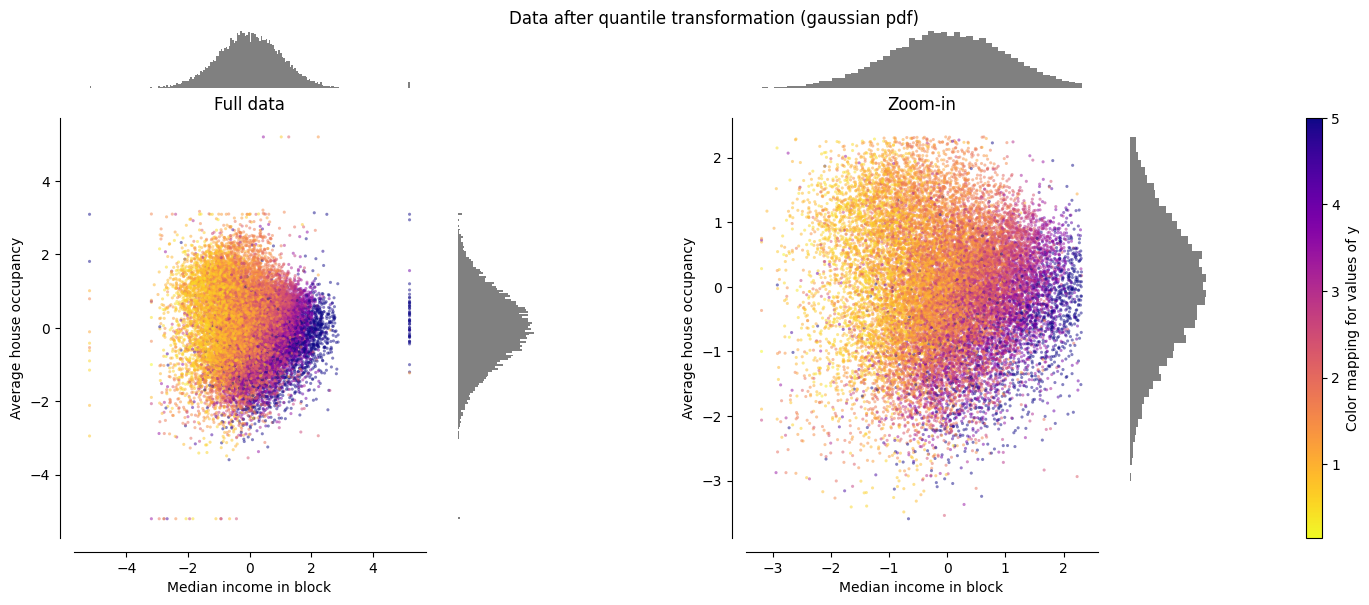

In [ ]:
make_plot(8)

### Normalizer

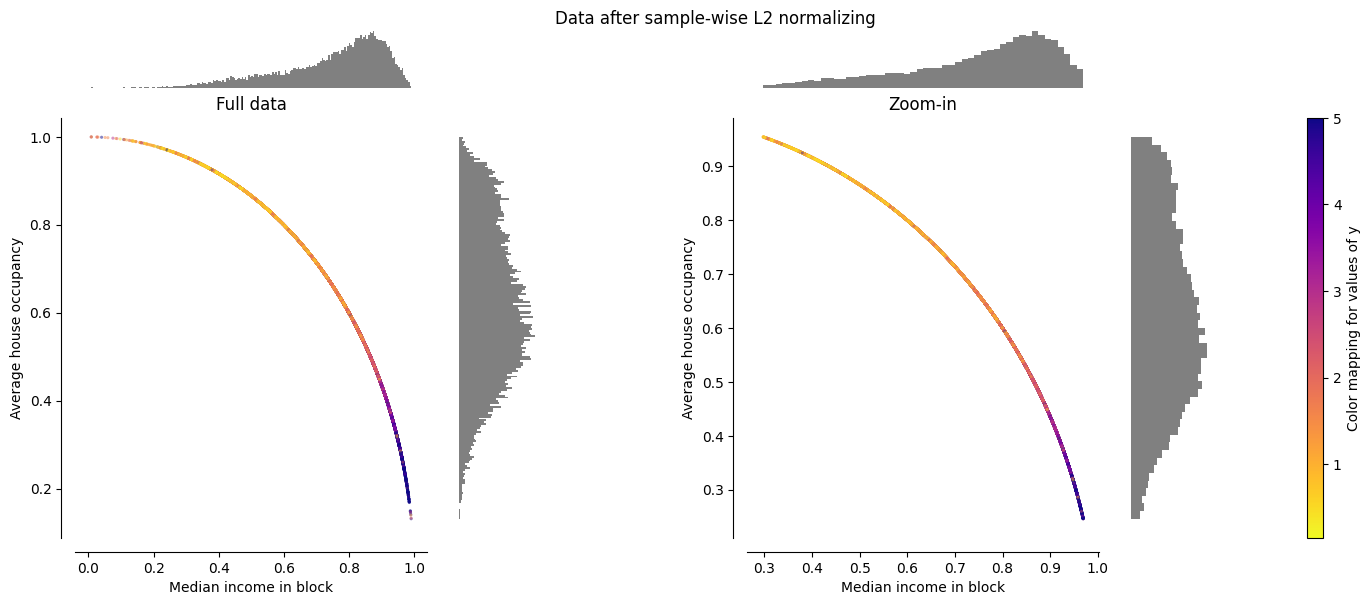

In [ ]:
make_plot(9)
plt.show()

## Cuestionario

### 1. Sensibilidad a los valores atípicos

Observa las gráficas de StandardScaler y MinMaxScaler. ¿Qué sucede con la masa principal de los datos (el "cuadrado" denso) cuando hay valores atípicos muy alejados? ¿Por qué estos escaladores podrían ser problemáticos en este escenario?

---

> Cuando hay valores atípicos muy alejados, la mayoría de los datos se ven comprimidos en las gráficas de **StandardScaler** y **MinMaxScaler**. Esto pasa porque ambos escaladores usan el valor más alto y más bajo (MinMax) o el promedio (Standard) de todos los datos, incluyendo los atípicos que distorsionan los cálculos.

### 2.Robustez
Compara el RobustScaler con el StandardScaler. Explica por qué el RobustScaler logra mantener el "zoom" en la mayoría de los datos a pesar de que los ejes sigan mostrando los valores extremos. ¿Qué estadísticos utiliza para lograr esto?

---

> El StandardScaler usa el promedio (media) y la desviación estándar para escalar. Si hay valores atípicos, estos afectan mucho a esos cálculos y comprimen el resto de los datos. En cambio, el RobustScaler usa la mediana para el centrado y el rango intercuartílico (IQR) para escalar. Estos estadísticos son mucho menos sensibles a los valores atípicos, lo que permite que la mayoría de los datos mantengan su distribución ('zoom') sin verse tan afectados, aunque los ejes sigan mostrando los valores extremos. La principal corrección es que RobustScaler usa el rango intercuartílico, no la desviación estándar.

### 3. Normalización de la distribución
El PowerTransformer (método Yeo-Johnson) y el QuantileTransformer (salida Gaussiana) intentan forzar los datos hacia una distribución normal.

¿Qué diferencias visuales notas entre ellos?

¿En qué tipo de modelos de aprendizaje automático crees que sería más beneficioso usar estas transformaciones en lugar de un simple escalado lineal?

---

¿Qué diferencias visuales notas entre ellos?

- PowerTransformer (Yeo-Johnson): Modifica suavemente la distribución, reduciendo la asimetría para asemejarse a una campana (gaussiana), sin forzar una forma perfecta. La estructura original es aún reconocible.
- QuantileTransformer (salida Gaussiana): Transforma drásticamente los datos para obtener una distribución Gaussiana explícita, independientemente de la forma original. Su objetivo es uniformizar la densidad de puntos dentro de la distribución resultante.

¿En qué tipo de modelos de aprendizaje automático crees que sería más beneficioso usar estas transformaciones en lugar de un simple escalado lineal?

Benefician a modelos que asumen o se desempeñan mejor con características de distribución Gaussiana o simétrica. Esto incluye modelos lineales (regresión), basados en distancia (K-Means, KNN) y técnicas como PCA, donde la normalidad de los datos puede mejorar la interpretación y el rendimiento.

### 4. El caso del Normalizer

> El Normalizer actúa sobre las filas (muestras) porque su objetivo es escalar cada **muestra individual** a una norma unitaria. Esto significa que la 'longitud' del vector de cada muestra se convierte en 1. No se enfoca en la distribución de las características a través de todas las muestras, sino en la proporción de cada característica *dentro de una única muestra*.

> Un caso de uso deseable es en **procesamiento de texto**, especialmente con vectores TF-IDF. Al normalizar, la longitud del documento (número de palabras) no influye indebidamente en la distancia entre documentos, y la importancia relativa de las palabras dentro de un documento se mantiene. También es útil en **química** para vectores de descriptores moleculares.

### 5. Conclusión técnica

> Elegiría el **RobustScaler**. La regresión lineal es sensible a los valores atípicos, que pueden distorsionar la estimación de los coeficientes. RobustScaler utiliza la mediana y el rango intercuartílico (IQR) para escalar, lo que lo hace mucho menos susceptible a la influencia de valores extremos en comparación con StandardScaler o MinMaxScaler. Esto ayuda a preservar la estructura de la masa principal de datos y a que el modelo no se vea indebidamente afectado por los outliers.